## Clean version of our assignment

Importing packages 

In [2]:
import pandas as pd
import os
import zipfile

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn import datasets as ds
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.decomposition import PCA
from sklearn import metrics
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import decomposition

from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import neighbors

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import sklearn.metrics as sklm
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.tree import plot_tree
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix, classification_report
from scipy.stats import ttest_ind

Load data 

In [3]:
with zipfile.ZipFile("ecg_data.zip","r") as zip_ref:
    zip_ref.extractall("ecg_data")

def load_data():
    this_directory = os.getcwd()
    data = pd.read_csv(os.path.join(this_directory, 'ecg_data/ecg_data.csv'), index_col=0)
    return data

raw_data = load_data()

Data description

In [4]:
print(f'The number of samples: {len(raw_data.index)}')
print(f'The number of columns: {len(raw_data.columns)}')

print(f'The number of NaN values in the entire dataframe: {raw_data.isnull().sum().sum()}')
print(f'The number of samples with label 0: {len(raw_data[raw_data["label"] == 0])}')
print(f'The number of samples with label 1: {len(raw_data[raw_data["label"] == 1])}')
print(f'The percentage of samples with label 0 is thus {len(raw_data[raw_data["label"] == 0])/len(raw_data.index)*100:.2f}%', 
      f'and the percentage with label 1 {len(raw_data[raw_data["label"] == 1])/len(raw_data.index)*100:.2f}%')

# print(raw_data.groupby('label').count())
# print(raw_data.groupby('label').mean())
# print(raw_data.groupby('label').var())
# print(raw_data.groupby('label').std())


The number of samples: 827
The number of columns: 9001
The number of NaN values in the entire dataframe: 0
The number of samples with label 0: 681
The number of samples with label 1: 146
The percentage of samples with label 0 is thus 82.35% and the percentage with label 1 17.65%


Splitting the data in training and test sets

In [5]:
X = raw_data.drop('label', axis=1)
Y = raw_data['label']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.25, random_state=4, stratify=Y)

Preprocessing

In [6]:
print(f"Preprocessing begint met {x_train.shape[1]} features")

# =========================
# 1. Variantie-filter op training set
# =========================
redundant_features_variance = []
for col in x_train.columns:
    if np.var(x_train[col]) < 0.01:
        redundant_features_variance.append(col)

x_train_var = x_train.drop(columns=redundant_features_variance)
x_test_var = x_test.drop(columns=redundant_features_variance)

print(f"Variantie-analyse verwijderde {len(redundant_features_variance)} features")

# =========================
# 2. Correlatie-filter op training set
# =========================
correlation_matrix = x_train_var.corr().abs()
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

redundant_features_correlation = [
    col for col in upper_triangle.columns if any(upper_triangle[col] > 0.95)
]

x_train_corr = x_train_var.drop(columns=redundant_features_correlation)
x_test_corr = x_test_var.drop(columns=redundant_features_correlation)

print(f"Correlatie-analyse verwijderde {len(redundant_features_correlation)} features")

# =========================
# 3. T-test filter op training set
# =========================
train_with_label = pd.concat([x_train_corr, y_train], axis=1)

redundant_features_ttest = []
for col in x_train_corr.columns:
    group0 = train_with_label[train_with_label["label"] == 0][col]
    group1 = train_with_label[train_with_label["label"] == 1][col]
    p_value = ttest_ind(group0, group1)[1]

    if p_value > (0.05 / x_train_corr.shape[1]):   # Bonferroni-correctie
        redundant_features_ttest.append(col)

x_train_t = x_train_corr.drop(columns=redundant_features_ttest)
x_test_t = x_test_corr.drop(columns=redundant_features_ttest)

print(f"T-test analyse verwijderde {len(redundant_features_ttest)} features")

# =========================
# 4. Schalen: fit op train, transform op test
# =========================
scaler = RobustScaler()

x_train_scaled = pd.DataFrame(
    scaler.fit_transform(x_train_t),
    columns=x_train_t.columns,
    index=x_train_t.index
)

x_test_scaled = pd.DataFrame(
    scaler.transform(x_test_t),
    columns=x_test_t.columns,
    index=x_test_t.index
)

print(f"Na preprocessing zijn er {x_train_scaled.shape[1]} features over")

Preprocessing begint met 9000 features
Variantie-analyse verwijderde 0 features
Correlatie-analyse verwijderde 5045 features
T-test analyse verwijderde 3917 features
Na preprocessing zijn er 38 features over


Threshold: 0.3
Accuracy: 0.8164251207729468
Precision: 0.48484848484848486
Recall: 0.43243243243243246
F1-score: 0.45714285714285713

Classification report:

              precision    recall  f1-score   support

           0       0.88      0.90      0.89       170
           1       0.48      0.43      0.46        37

    accuracy                           0.82       207
   macro avg       0.68      0.67      0.67       207
weighted avg       0.81      0.82      0.81       207

Confusion Matrix:
 [[153  17]
 [ 21  16]]


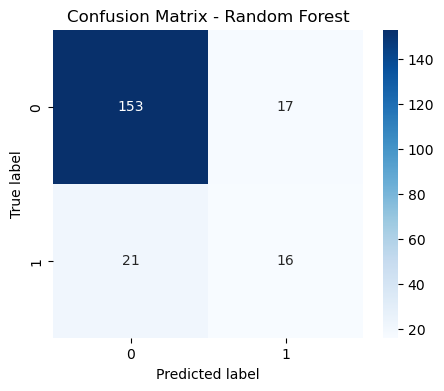

In [10]:
##Uitvoeren van Random forest classifier op de verschillende preprocessed datasets 
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
)

# Train het model
rf.fit(x_train_scaled, y_train)

# Maak voorspellingen
y_pred = rf.predict(x_test_scaled)

# Predict probabilities
y_prob = rf.predict_proba(x_test_scaled)[:, 1]

# Pas threshold aan
threshold = 0.3
y_pred_custom = (y_prob > threshold).astype(int)

# Evaluatie van het model met aangepaste threshold
print(f"Threshold: {threshold}")
print("Accuracy:", metrics.accuracy_score(y_test, y_pred_custom))
print("Precision:", precision_score(y_test, y_pred_custom))
print("Recall:", recall_score(y_test, y_pred_custom))
print("F1-score:", f1_score(y_test, y_pred_custom))

print("\nClassification report:\n")
print(classification_report(y_test, y_pred_custom))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_custom)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - Random Forest")
plt.show()

c:\Users\yalci\miniforge3\envs\TM10011\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Accuracy: 0.8357487922705314
Precision: 0.6153846153846154
Recall: 0.21621621621621623
F1-score: 0.32

Classification report:

              precision    recall  f1-score   support

           0       0.85      0.97      0.91       170
           1       0.62      0.22      0.32        37

    accuracy                           0.84       207
   macro avg       0.73      0.59      0.61       207
weighted avg       0.81      0.84      0.80       207

Confusion Matrix:
 [[165   5]
 [ 29   8]]


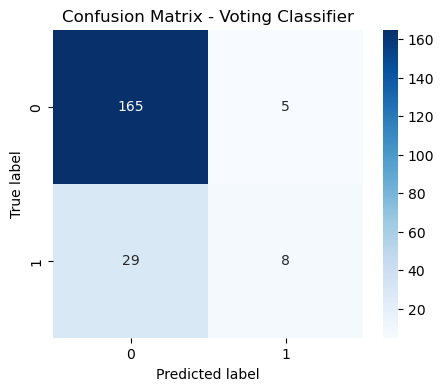

In [8]:
#Voting classifier met Logistic Regression, KNN en Decision Tree als base classifiers
from sklearn.ensemble import VotingClassifier

lr = LogisticRegression(max_iter=1000, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)
dt = DecisionTreeClassifier(random_state=42)

voting = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('knn', knn),
        ('dt', dt)
    ],
    voting='soft'
)

# Train het model
voting.fit(x_train_scaled, y_train)

# Maak voorspellingen
y_pred_vote = voting.predict(x_test_scaled)

# =========================
# Evaluatie
# =========================
print("Accuracy:", metrics.accuracy_score(y_test, y_pred_vote))
print("Precision:", precision_score(y_test, y_pred_vote))
print("Recall:", recall_score(y_test, y_pred_vote))
print("F1-score:", f1_score(y_test, y_pred_vote))

print("\nClassification report:\n")
print(classification_report(y_test, y_pred_vote))

# =========================
# Confusion matrix
# =========================
cm_vote = confusion_matrix(y_test, y_pred_vote)
print("Confusion Matrix:\n", cm_vote)

plt.figure(figsize=(5,4))
sns.heatmap(cm_vote, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - Voting Classifier")
plt.show()

Preprocessing of data

In [10]:
###De gekozen volgorde van variantie -> lineaire correlatie -> t-test -> schalen heeft met name te maken met runtime verminderen
###         Daarnaast is schalen vóór de variantie-analyse sowieso niet handig, want dan schaalt de variantie schijnbaar mee
###             Dit komt door de gekozen schaalwijze
###         In deze volgorde zou nog geschoven kunnen worden als dat handig is.

print(f"Preprocessing begint met {np.shape(X)[1]} features")

### Filter de originele features o.b.v. variantie
###         Indien de variantie < 0.01 is, worden ze verwijderd.
###         Dit komt echter niet voor in onze dataset, dus dit verminderd het aantal features niet.
###             Dit zou kunnen komen door de outliers, ik weet niet zo goed of hier wat aan te doen is.
###     Eindresultaat --> 9000 features
redundant_features_variance = []
for col in X:
    if np.var(X[col]) < 0.01:
        redundant_features_variance.append(col)
X_variance_filtered = X.drop(columns=redundant_features_variance)

print(f"Variantie-analyse verwijderde {np.size(redundant_features_variance)} features")

### Filter de features o.b.v. lineaire correlatie
###         Indien de lineaire correlatie tussen twee features > 0.95 is, of < -0.95, dan wordt een van de twee verwijderd.
###         Hiermee kunnen 4574 features worden verwijderd.
###     Eindresultaat --> 4426 features

correlation_matrix = X_variance_filtered.corr().abs()
correlation_matrix_no_duplicates = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
redundant_features_correlation = []
for col in correlation_matrix:
    if any(correlation_matrix_no_duplicates[col] > 0.95):
        redundant_features_correlation.append(col)
X_correlation_filtered = X_variance_filtered.drop(columns=redundant_features_correlation)

print(f"Correlatie analyse verwijderde {np.size(redundant_features_correlation)} features")

### Filter de features o.b.v. t-test score
###         Indien de p-waarde van de t-test > 0.95, dan wordt deze verwijderd.
###             Hier gaat wel een Bonferonni correctie overheen, omdat anders bij toeval onzinnige features worden toegelaten.
###         De gedachte hierachter is dat deze features niet in staat om een verschil tussen de twee ECG-types aan te tonen.
###         T-test kan ook nog vervangen worden voor Mann-Whitney U test.
###             Bij een groot aantal samples zou T-test gebruikt mogen worden, ook als data niet normaal verdeeld is.
###             Maar wellicht iets om te vervangen als nodig.
###         Hiermee kunnen 4365 features worden verwijderd.
###     Eindresultaat --> 61 features
X_ttest_unfiltered_with_label = pd.concat([X_correlation_filtered, Y], axis=1)
redundant_features_ttest = []
for col in correlation_matrix:
    if any(correlation_matrix_no_duplicates[col] > 0.95):
        redundant_features_correlation.append(col)
X_correlation_filtered = X_variance_filtered.drop(columns=redundant_features_correlation)

print(f"Correlatie analyse verwijderde {np.size(redundant_features_correlation)} features")

### Filter de features o.b.v. t-test score
###         Indien de p-waarde van de t-test > 0.95, dan wordt deze verwijderd.
###             Hier gaat wel een Bonferonni correctie overheen, omdat anders bij toeval onzinnige features worden toegelaten.
###         De gedachte hierachter is dat deze features niet in staat om een verschil tussen de twee ECG-types aan te tonen.
###         T-test kan ook nog vervangen worden voor Mann-Whitney U test.
###             Bij een groot aantal samples zou T-test gebruikt mogen worden, ook als data niet normaal verdeeld is.
###             Maar wellicht iets om te vervangen als nodig.
###         Hiermee kunnen 4365 features worden verwijderd.
###     Eindresultaat --> 61 features
X_ttest_unfiltered_with_label = pd.concat([X_correlation_filtered, Y], axis=1)
redundant_features_ttest = []
for col in X_correlation_filtered:
    p_value = ttest_ind(X_ttest_unfiltered_with_label[X_ttest_unfiltered_with_label["label"] == 0][col], X_ttest_unfiltered_with_label[X_ttest_unfiltered_with_label["label"] == 1][col])[1]
    if p_value > (0.05/np.shape(X_correlation_filtered)[1]):
        redundant_features_ttest.append(col)
X_ttest_filtered = X_correlation_filtered.drop(columns=redundant_features_ttest)

print(f"T-test analyse verwijderde {np.size(redundant_features_ttest)} features")

### Schaal de data om orde-grootte verschillen te beperken.
###         Hier gekozen voor Robuust, omdat de data (vgm) niet normaal verdeeld is en outliers bevat.
###         Omgang met missende data hier niet nodig, onze dataset bevat geen NaN.
###         Doordat we niet weten wat de features in onze dataset betekenen, kunnen we onrealistische waarden ook niet verwijderen.
scaler = RobustScaler()
preprocessed_data = pd.DataFrame(scaler.fit_transform(X_ttest_filtered), columns=X_ttest_filtered.columns)

print(f"Na het schalen zijn er {np.shape(preprocessed_data)[1]} features over")

Preprocessing begint met 9000 features
Variantie-analyse verwijderde 0 features
Correlatie analyse verwijderde 4574 features
Correlatie analyse verwijderde 9148 features
T-test analyse verwijderde 4365 features
Na het schalen zijn er 61 features over
